In [ ]:
#Appendix 1A - Lagrange interpolation for Thermophysical Properties

import numpy as np

# -----------------------------
# R245fa saturation property data
# -----------------------------
T_data_C = np.array([15.1, 30.0, 46.0, 60.0])          # °C

rho_l_data = np.array([1365.0, 1325.0, 1279.0, 1267.0])      # kg/m^3
rho_v_data = np.array([5.961, 10.169, 17.30, 25.68])         # kg/m^3
mu_l_data  = np.array([464e-6, 382e-6, 314e-6, 266e-6])      # Pa·s
mu_v_data  = np.array([9.93e-6, 10.4e-6, 11.0e-6, 11.5e-6])  # Pa·s
k_l_data   = np.array([0.0912, 0.0865, 0.0814, 0.0769])      # W/m·K
h_lv_data  = np.array([196.1e3, 187.0e3, 177.2e3, 168.0e3])  # J/kg
sigma_data = np.array([0.0153, 0.0134, 0.0114, 0.0096])      # N/m
cp_l_data  = np.array([1318.0, 1350.0, 1388.0, 1428.0])      # J/kg·K

# Tsat(P) constants
C0 = 20.472
C1 = -2579.9


def lagrange_interp(x, xdata, ydata):
    n = len(xdata)
    y = 0.0
    for i in range(n):
        Li = 1.0
        for j in range(n):
            if i != j:
                Li *= (x - xdata[j]) / (xdata[i] - xdata[j])
        y += ydata[i] * Li
    return y


def Tsat_from_P(P_kPa):
    P_Pa = P_kPa * 1000.0
    Tsat_K = C1 / (np.log(P_Pa) - C0)
    return Tsat_K


def r245fa_sat_props(P_kPa):
    Tsat_K = Tsat_from_P(P_kPa)
    Tsat_C = Tsat_K - 273.15

    rho_l = lagrange_interp(Tsat_C, T_data_C, rho_l_data)
    rho_v = lagrange_interp(Tsat_C, T_data_C, rho_v_data)
    mu_l  = lagrange_interp(Tsat_C, T_data_C, mu_l_data)
    mu_v  = lagrange_interp(Tsat_C, T_data_C, mu_v_data)
    k_l   = lagrange_interp(Tsat_C, T_data_C, k_l_data)
    h_lv  = lagrange_interp(Tsat_C, T_data_C, h_lv_data)
    sigma = lagrange_interp(Tsat_C, T_data_C, sigma_data)
    cp_l  = lagrange_interp(Tsat_C, T_data_C, cp_l_data)

    Pr_l = mu_l * cp_l / k_l

    return {
        "Tsat_K": Tsat_K,
        "Tsat_C": Tsat_C,
        "rho_l": rho_l,
        "rho_v": rho_v,
        "mu_l": mu_l,
        "mu_v": mu_v,
        "k_l": k_l,
        "h_lv": h_lv,
        "sigma": sigma,
        "cp_l": cp_l,
        "Pr_l": Pr_l
    }


# Example evaluation for Task 1 inlet pressure
props = r245fa_sat_props(220.0)

units = {
    "Tsat_K": "K",
    "Tsat_C": "°C",
    "rho_l": "kg/m^3",
    "rho_v": "kg/m^3",
    "mu_l": "Pa·s",
    "mu_v": "Pa·s",
    "k_l": "W/m·K",
    "h_lv": "J/kg",
    "sigma": "N/m",
    "cp_l": "J/kg·K",
    "Pr_l": "-"
}

for key, val in props.items():
    print(f"{key:8s} = {val:.6f} {units[key]}")

Tsat_K   = 315.753381 K
Tsat_C   = 42.603381 °C
rho_l    = 1287.103727 kg/m^3
rho_v    = 15.564896 kg/m^3
mu_l     = 0.000327 Pa·s
mu_v     = 0.000011 Pa·s
k_l      = 0.082487 W/m·K
h_lv     = 179320.396169 J/kg
sigma    = 0.011826 N/m
cp_l     = 1379.389562 J/kg·K
Pr_l     = 5.469024 -


In [ ]:
#Appendix A2 - Single Segment Condenser Element

def segment_model(
    q_chip=340.0,       # W
    Ta_in_C=20.0,       # °C
    Va=6.5,             # m/s
    P_in_kPa=220.0,     # kPa
    dz=0.040,           # m
    D=0.003,            # m
    n_tubes=9,          # -
    x_in=0.999,         # -
    rho_a=1.3,          # kg/m^3
    cp_a=1005.0,        # J/kg·K
    Lf=5.26e-3,         # m
    g=9.81              # m/s^2
):
    props = r245fa_sat_props(P_in_kPa)

    Tsat_K = props["Tsat_K"]
    rho_l = props["rho_l"]
    rho_v = props["rho_v"]
    mu_l = props["mu_l"]
    mu_v = props["mu_v"]
    k_l = props["k_l"]
    h_lv = props["h_lv"]
    sigma = props["sigma"]
    Pr_l = props["Pr_l"]

    Ta_in_K = Ta_in_C + 273.15

    # Mass flux
    A_passage = np.pi * D**2 / 4.0                      # m^2
    A_total = n_tubes * A_passage                       # m^2
    G = q_chip / (A_total * h_lv)                       # kg/m^2·s

    # Reynolds numbers
    Re_lo = G * D / mu_l
    Re_l = G * (1.0 - x_in) * D / mu_l
    Re_vo = G * D / mu_v

    # Martinelli parameter
    X_tt = ((1.0 - x_in) / x_in)**0.9 * (rho_v / rho_l)**0.5 * (mu_l / mu_v)**0.1

    # Traviss F_T
    if Re_l > 1125:
        F_T = 0.812 * (Pr_l**0.5) + 5.0 * np.log(1.0 + 5.0 * Pr_l) + 2.5 * np.log(0.0031 * Re_l)
    elif Re_l > 50:
        F_T = 0.585 * (Pr_l**0.5) + 5.0 * np.log(1.0 + Pr_l * (0.0964 * Re_l**0.585 - 1.0))
    else:
        F_T = 0.5 * (Pr_l**0.5) * Re_l

    # Refrigerant-side heat transfer coefficient
    hr = (k_l / D) * 0.15 * (Pr_l**0.4) * (Re_l**0.9) * F_T * (1.0 / X_tt + 2.85 / X_tt**0.476)

    # Inlet void fraction
    alpha_in = 1.0 / (
        1.0
        + ((1.0 - x_in) / x_in)**0.64
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Segment UA and heat transfer
    Ar = n_tubes * np.pi * D * dz                       # m^2
    UA_air = 77.1 * (Va / 6.5)**0.5 * dz               # W/K
    UA_seg = 1.0 / (1.0 / (hr * Ar) + 1.0 / UA_air)    # W/K

    m_dot_a_seg = rho_a * Va * (2.0 * Lf) * dz         # kg/s
    C_a_seg = m_dot_a_seg * cp_a                       # W/K
    NTU = UA_seg / C_a_seg
    eps_seg = 1.0 - np.exp(-NTU)

    q_seg = C_a_seg * (Tsat_K - Ta_in_K) * eps_seg     # W

    # Exit quality
    x_out = x_in - q_seg / q_chip
    if x_out < 0.0:
        x_out = 1.0e-5
        q_seg = (x_in - x_out) * q_chip

    # Exit void fraction
    alpha_out = 1.0 / (
        1.0
        + ((1.0 - x_out) / x_out)**0.64
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Pressure drop model
    Gamma_in = G**2 * (
        x_in**2 / (rho_v * alpha_in)
        + (1.0 - x_in)**2 / (rho_l * (1.0 - alpha_in))
    )

    Gamma_out = G**2 * (
        x_out**2 / (rho_v * alpha_out)
        + (1.0 - x_out)**2 / (rho_l * (1.0 - alpha_out))
    )

    f_lo = 16.0 / Re_lo
    dPdz_lo = 2.0 * G**2 * f_lo / (D * rho_l)          # Pa/m

    if Re_vo < 2300.0:
        f_vo = 16.0 / Re_vo
    else:
        f_vo = 0.079 * Re_vo**(-0.25)

    rho_tp = 1.0 / (x_in / rho_v + (1.0 - x_in) / rho_l)
    Fr = G**2 / (rho_tp**2 * g * D)
    We = G**2 * D / (rho_tp * sigma)

    E = (1.0 - x_in)**2 + x_in**2 * (rho_l * f_vo) / (rho_v * f_lo)
    F = x_in**0.78 * (1.0 - x_in)**0.224
    H = (rho_l / rho_v)**0.91 * (mu_v / mu_l)**0.19 * (1.0 - mu_v / mu_l)**0.7

    phi_lo_sq = E + 3.24 * F * H / (Fr**0.045 * We**0.035)

    P_in_Pa = P_in_kPa * 1000.0
    P_out_Pa = P_in_Pa - phi_lo_sq * dPdz_lo * dz - (Gamma_out - Gamma_in)
    P_out_kPa = P_out_Pa / 1000.0

    return {
        "Tsat_C": props["Tsat_C"],          # °C
        "G": G,                             # kg/m^2·s
        "hr": hr,                           # W/m^2·K
        "UA_seg": UA_seg,                   # W/K
        "q_seg": q_seg,                     # W
        "x_out": x_out,                     # -
        "alpha_in": alpha_in,               # -
        "alpha_out": alpha_out,             # -
        "phi_lo_sq": phi_lo_sq,             # -
        "P_out_kPa": P_out_kPa              # kPa
    }

In [ ]:
results = segment_model()

for key, value in results.items():
    if key == "Tsat_C":
        print(f"{key:12s} = {value:.6f} °C")
    elif key == "G":
        print(f"{key:12s} = {value:.6f} kg/m^2·s")
    elif key == "hr":
        print(f"{key:12s} = {value:.6f} W/m^2·K")
    elif key == "UA_seg":
        print(f"{key:12s} = {value:.6f} W/K")
    elif key == "q_seg":
        print(f"{key:12s} = {value:.6f} W")
    elif key == "P_out_kPa":
        print(f"{key:12s} = {value:.6f} kPa")
    else:
        print(f"{key:12s} = {value:.6f} -")

Tsat_C       = 42.603381 °C
G            = 29.803984 kg/m^2·s
hr           = 2731.501028 W/m^2·K
UA_seg       = 2.313984 W/K
q_seg        = 38.502144 W
x_out        = 0.885758 -
alpha_in     = 0.996895 -
alpha_out    = 0.934745 -
phi_lo_sq    = 26.055362 -
P_out_kPa    = 219.981031 kPa


**'''Beggining of Asal's Code'''**

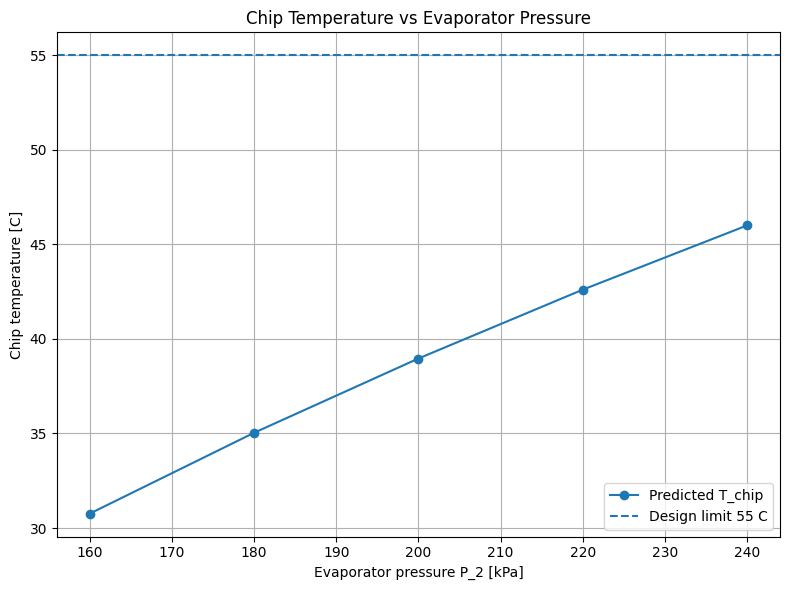


[Part 1] Design evaporator pressure: 285.63 kPa, chip will be at 55C


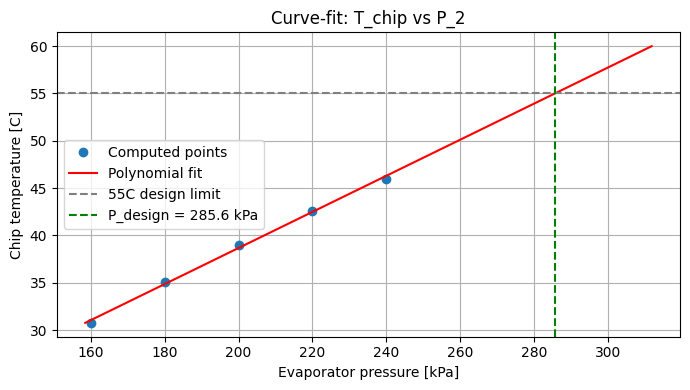


[Part 2a] Condenser Full Length Results
 Seg    x_out    α_out P_out (kPa)  q_seg (W)
   1  0.83168  0.90611     285.6209    56.8901
   2  0.64013  0.83386     285.5943    65.1266
   3  0.44096  0.74891     285.5687    67.7177
   4  0.24164  0.62545     285.5465    67.7671
   5  0.04256  0.32129     285.5299    67.6888
   6  0.00001  0.00219     285.5231    14.4663
   7  0.00001  0.00219     285.5220     0.0000
   8  0.00001  0.00219     285.5210     0.0000
   9  0.00001  0.00219     285.5200     0.0000
  10  0.00001  0.00219     285.5190     0.0000
  11  0.00001  0.00219     285.5180     0.0000
  12  0.00001  0.00219     285.5170     0.0000
  13  0.00001  0.00219     285.5160     0.0000
  14  0.00001  0.00219     285.5149     0.0000
  15  0.00001  0.00219     285.5139     0.0000
  16  0.00001  0.00219     285.5129     0.0000
  17  0.00001  0.00219     285.5119     0.0000
  18  0.00001  0.00219     285.5109     0.0000
  19  0.00001  0.00219     285.5099     0.0000
  20  0.00001  0.002

In [ ]:
''' Task 2 '''

import numpy as np
import math
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as P

#define the five evaporator pressures (P2)
P2_vals = [160.0, 180.0, 200.0, 220.0, 240.0] #kPa

q_chip=340.0       # W
Ta_in_C=20.0       # C
Va=6.5             # m/s
dz=0.040         # m
D=0.003            # m
n_tubes=9          # -
rho_a=1.3          # kg/m^3
g=9.81              # m/s^2
segments_count = 20     #number of segments
A_chip = (6e-2)**2  #m^2
q_double_dot = q_chip/A_chip #W/m^2
T_design_chip = 55.0 + 273.15 #K
theta = 35 * np.pi/180.0 #radians

#from the image in the description of Task 2
x_s0= 0.999
alpha_s0 = 0.999

cp_a=1005.0        # J/kg·K
Lf=5.26e-3         # m

# Tsat(P2) constants
C0 = 20.472
C1 = -2579.9

#Lagrange interpolation for Thermophysical Properties

# -----------------------------
# R245fa saturation property data
# -----------------------------
T_data_C = np.array([15.1, 30.0, 46.0, 60.0])          #C

rho_l_data = np.array([1365.0, 1325.0, 1279.0, 1267.0])      # kg/m^3
rho_v_data = np.array([5.961, 10.169, 17.30, 25.68])         # kg/m^3
mu_l_data  = np.array([464e-6, 382e-6, 314e-6, 266e-6])      # Pa·s
mu_v_data  = np.array([9.93e-6, 10.4e-6, 11.0e-6, 11.5e-6])  # Pa·s
k_l_data   = np.array([0.0912, 0.0865, 0.0814, 0.0769])      # W/m·K
h_lv_data  = np.array([196.1e3, 187.0e3, 177.2e3, 168.0e3])  # J/kg0.
sigma_data = np.array([0.0153, 0.0134, 0.0114, 0.0096])      # N/m
cp_l_data  = np.array([1318.0, 1350.0, 1388.0, 1428.0])      # J/kg·K

def lagrange_interp(x, xdata, ydata):
    n = len(xdata)
    y = 0.0
    for i in range(n):
        Li = 1.0
        for j in range(n):
            if i != j:
                Li *= (x - xdata[j]) / (xdata[i] - xdata[j])
        y += ydata[i] * Li
    return y


def Tsat_from_P(P_kPa):
    P_Pa = P_kPa * 1000.0
    Tsat_K = C1 / (np.log(P_Pa) - C0)
    return Tsat_K


def r245fa_sat_props(P_kPa):
    Tsat_K = Tsat_from_P(P_kPa)
    Tsat_C = Tsat_K - 273.15

    rho_l = lagrange_interp(Tsat_C, T_data_C, rho_l_data)
    rho_v = lagrange_interp(Tsat_C, T_data_C, rho_v_data)
    mu_l  = lagrange_interp(Tsat_C, T_data_C, mu_l_data)
    mu_v  = lagrange_interp(Tsat_C, T_data_C, mu_v_data)
    k_l   = lagrange_interp(Tsat_C, T_data_C, k_l_data)
    h_lv  = lagrange_interp(Tsat_C, T_data_C, h_lv_data)
    sigma = lagrange_interp(Tsat_C, T_data_C, sigma_data)
    cp_l  = lagrange_interp(Tsat_C, T_data_C, cp_l_data)

    Pr_l = mu_l * cp_l / k_l

    return {
        "Tsat_K": Tsat_K,
        "Tsat_C": Tsat_C,
        "rho_l": rho_l,
        "rho_v": rho_v,
        "mu_l": mu_l,
        "mu_v": mu_v,
        "k_l": k_l,
        "h_lv": h_lv,
        "sigma": sigma,
        "cp_l": cp_l,
        "Pr_l": Pr_l
    }

units = {
    "Tsat_K": "K",
    "Tsat_C": "°C",
    "rho_l": "kg/m^3",
    "rho_v": "kg/m^3",
    "mu_l": "Pa·s",
    "mu_v": "Pa·s",
    "k_l": "W/m·K",
    "h_lv": "J/kg",
    "sigma": "N/m",
    "cp_l": "J/kg·K",
    "Pr_l": "-"
}


#repeated from Task 1 to define the segment calculating functio:
#Single Segment Condenser Element

def segment_model(
    q_chip=340.0,       # W
    Ta_in_C=20.0,       # °C
    Va=6.5,             # m/s
    P_in_kPa=220.0,     # kPa
    dz=0.040,           # m
    D=0.003,            # m
    n_tubes=9,          # -
    x_in=0.999,         # -
    rho_a=1.3,          # kg/m^3
    cp_a=1005.0,        # J/kg·K
    Lf=5.26e-3,         # m
    g=9.81              # m/s^2
):
    props = r245fa_sat_props(P_in_kPa)

    Tsat_K = props["Tsat_K"]
    rho_l = props["rho_l"]
    rho_v = props["rho_v"]
    mu_l = props["mu_l"]
    mu_v = props["mu_v"]
    k_l = props["k_l"]
    h_lv = props["h_lv"]
    sigma = props["sigma"]
    Pr_l = props["Pr_l"]

    Ta_in_K = Ta_in_C + 273.15

    # Mass flux
    A_passage = np.pi * D**2 / 4.0                      # m^2
    A_total = n_tubes * A_passage                       # m^2
    G = q_chip / (A_total * h_lv)                       # kg/m^2·s

    # Reynolds numbers
    Re_lo = G * D / mu_l
    Re_l = G * (1.0 - x_in) * D / mu_l
    Re_vo = G * D / mu_v

    # Martinelli parameter
    X_tt = ((1.0 - x_in) / x_in)**0.9 * (rho_v / rho_l)**0.5 * (mu_l / mu_v)**0.1

    # Traviss F_T
    if Re_l > 1125:
        F_T = 0.812 * (Pr_l**0.5) + 5.0 * np.log(1.0 + 5.0 * Pr_l) + 2.5 * np.log(0.0031 * Re_l)
    elif Re_l > 50:
        F_T = 0.585 * (Pr_l**0.5) + 5.0 * np.log(1.0 + Pr_l * (0.0964 * Re_l**0.585 - 1.0))
    else:
        F_T = 0.5 * (Pr_l**0.5) * Re_l

    # Refrigerant-side heat transfer coefficient
    hr = (k_l / D) * 0.15 * (Pr_l**0.4) * (Re_l**0.9) * F_T * (1.0 / X_tt + 2.85 / X_tt**0.476)

    # Inlet void fraction
    alpha_in = 1.0 / (
        1.0
        + ((1.0 - x_in) / x_in)**0.64
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Segment UA and heat transfer
    Ar = n_tubes * np.pi * D * dz                       # m^2
    UA_air = 77.1 * (Va / 6.5)**0.5 * dz               # W/K
    UA_seg = 1.0 / (1.0 / (hr * Ar) + 1.0 / UA_air)    # W/K

    m_dot_a_seg = rho_a * Va * (2.0 * Lf) * dz         # kg/s
    C_a_seg = m_dot_a_seg * cp_a                       # W/K
    NTU = UA_seg / C_a_seg
    eps_seg = 1.0 - np.exp(-NTU)

    q_seg = C_a_seg * (Tsat_K - Ta_in_K) * eps_seg     # W

    # Exit quality
    x_out = x_in - q_seg / q_chip
    if x_out < 0.0:
        x_out = 1.0e-5
        q_seg = (x_in - x_out) * q_chip

    # Exit void fraction
    alpha_out = 1.0 / (
        1.0
        + ((1.0 - x_out) / x_out)**0.64
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Pressure drop model
    Gamma_in = G**2 * (
        x_in**2 / (rho_v * alpha_in)
        + (1.0 - x_in)**2 / (rho_l * (1.0 - alpha_in))
    )

    Gamma_out = G**2 * (
        x_out**2 / (rho_v * alpha_out)
        + (1.0 - x_out)**2 / (rho_l * (1.0 - alpha_out))
    )

    f_lo = 16.0 / Re_lo
    dPdz_lo = 2.0 * G**2 * f_lo / (D * rho_l)          # Pa/m

    if Re_vo < 2300.0:
        f_vo = 16.0 / Re_vo
    else:
        f_vo = 0.079 * Re_vo**(-0.25)

    rho_tp = 1.0 / (x_in / rho_v + (1.0 - x_in) / rho_l)
    Fr = G**2 / (rho_tp**2 * g * D)
    We = G**2 * D / (rho_tp * sigma)

    E = (1.0 - x_in)**2 + x_in**2 * (rho_l * f_vo) / (rho_v * f_lo)
    F = x_in**0.78 * (1.0 - x_in)**0.224
    H = (rho_l / rho_v)**0.91 * (mu_v / mu_l)**0.19 * (1.0 - mu_v / mu_l)**0.7

    phi_lo_sq = E + 3.24 * F * H / (Fr**0.045 * We**0.035)

    P_in_Pa = P_in_kPa * 1000.0
    P_out_Pa = P_in_Pa - phi_lo_sq * dPdz_lo * dz - (Gamma_out - Gamma_in)
    P_out_kPa = P_out_Pa / 1000.0

    return {
        "Tsat_C": props["Tsat_C"],          # °C
        "G": G,                             # kg/m^2·s
        "hr": hr,                           # W/m^2·K
        "UA_seg": UA_seg,                   # W/K
        "q_seg": q_seg,                     # W
        "x_out": x_out,                     # -
        "alpha_in": alpha_in,               # -
        "alpha_out": alpha_out,             # -
        "phi_lo_sq": phi_lo_sq,             # -
        "P_out_kPa": P_out_kPa              # kPa
    }

## Part 1 -------------------------------------------------------------------------------------------------------------------------

#find T_sat and T_w
def T_wall_calculator(q_chip, A_chip, T_chip_design_K, P_vals):
    '''
    Find T_w and the pressure that satisfies the chip temperature limit.
    '''
    T_chip_list = []
    for P_kPa in P_vals:
        props = r245fa_sat_props(P_kPa)
        Tsat  = props["Tsat_K"]
        rho_l = props["rho_l"]
        rho_v = props["rho_v"]
        k_l   = props["k_l"]
        Pr_l  = props["Pr_l"]
        sigma = props["sigma"]

        #to find T_w:

        Db = 0.0208 * theta * np.sqrt(sigma / (g * (rho_l - rho_v)))

        # B = (rho_v / rho_l)^0.581 * Pr_l^0.533
        # use the rearranged eq from notes: T_w = [(1/207)(q_double_dot*Db/k_l)(k_l*T_sat/q_double_dot*Db)^0.745 *(B)^-1] + T_sat

        B = ((rho_v / rho_l)**0.581) * (Pr_l**0.533)
        T_wall = [(1/207)*(q_double_dot*Db/k_l)*((k_l*Tsat/q_double_dot*Db)**0.745) *(B**(-1))] + Tsat

        T_chip_list.append(T_wall)

    return T_chip_list

#plot T_chip vs P_ev for Part 1 Deliverable
T_chip_list = T_wall_calculator(q_chip, A_chip, T_design_chip, P2_vals)
T_chip_C = [T - 273.15 for T in T_chip_list]

plt.figure(figsize=(8, 6))
plt.plot(P2_vals, T_chip_C, 'o-', label='Predicted T_chip')
plt.axhline(T_design_chip - 273.15, linestyle='--', label=f'Design limit {T_design_chip-273.15:.0f} C')
plt.xlabel('Evaporator pressure P_2 [kPa]')
plt.ylabel('Chip temperature [C]')
plt.title('Chip Temperature vs Evaporator Pressure')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Use a curve-fit to find the evaporator pressure that satisfies the specified q_dot at T_chip = 55C
P_array = np.array(P2_vals)
T_array = np.array(T_chip_list).flatten()

#fit a first degree polynomial to T_chip vs P_2 -> P_2(T_chip) since T_chip is independent
coeffs = np.polyfit(T_array - 273.15, P_array, deg=1)
poly   = np.poly1d(coeffs)

#evaluate P at T_chip = 55°C
P_design = poly(55.0)

print(f"\n[Part 1] Design evaporator pressure: {P_design:.2f} kPa, chip will be at 55C")


#check the fit on the plot
T_plot = np.linspace(min(T_array - 273.15), 60.0, 200)
plt.figure(figsize=(7, 4))
plt.plot(P_array, T_array - 273.15, 'o', label='Computed points')
plt.plot(poly(T_plot), T_plot, 'r-', label='Polynomial fit')
plt.axhline(55.0, color='gray', linestyle='--', label='55C design limit')
plt.axvline(P_design, color='green', linestyle='--', label=f'P_design = {P_design:.1f} kPa')
plt.xlabel('Evaporator pressure [kPa]')
plt.ylabel('Chip temperature [C]')
plt.title('Curve-fit: T_chip vs P_2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Part 2 -------------------------------------------------------------------------------------------------------------------

#part 2(a) Loop and Sim Setup for Full Condenser
def condenser_sim(q_chip, Ta_in_C, Va, P_design, dz, D, n_tubes, segments_count, rho_a, cp_a, Lf, g):
    '''
    Iterates through the 20 condenser segments, returning exit states of all segments and the total
    properties of heat transfer rate and pressure drop and final exit state of the condenser exit.
    '''
    #at inlet of s0: saturated vapour at evaporator pressure enters condenser
    x = x_s0
    P_kPa = P_design

    records = []
    q_total   = 0.0
    dP_total  = 0.0

    for i in range(segments_count):
        res = segment_model(
            q_chip  = q_chip, Ta_in_C = Ta_in_C, Va = Va,
            P_in_kPa= P_kPa, dz = dz, D = D, n_tubes = n_tubes, x_in = x,
            rho_a = rho_a, cp_a = cp_a, Lf = Lf, g = g
            )

        x_out = res["x_out"]
        alpha_out = res["alpha_out"]
        P_out_kPa = res["P_out_kPa"]
        q_seg = res["q_seg"]

        records.append({
            "seg"      : i + 1,
            "x_out"    : x_out,
            "alpha_out": alpha_out,
            "P_out_kPa": P_out_kPa,
            "q_seg"    : q_seg
        })

        #total rate of heat transfer calc
        q_total  += q_seg
        #total pressure drop calc
        dP_total += (P_kPa - P_out_kPa)

        #next segment state information
        x = x_out
        P_kPa = P_out_kPa

    return records, q_total, dP_total, P_kPa, x, alpha_out


#report the requested values for Part 2(a)
#export the requested values in Part 2(a) by calling the function defined above that houses the segments for loop
records, q_total, dP_total, P_final_kPa, x_final, alpha_final = condenser_sim(q_chip, Ta_in_C, Va, P_design, dz,
                                                                 D, n_tubes, segments_count, rho_a, cp_a, Lf, g)
print("\n[Part 2a] Condenser Full Length Results")
print(f"{'Seg':>4} {'x_out':>8} {'α_out':>8} {'P_out (kPa)':>10} {'q_seg (W)':>10}")

for r in records:
    print(f"{r['seg']:>4} {r['x_out']:>8.5f} {r['alpha_out']:>8.5f} {r['P_out_kPa']:>12.4f} {r['q_seg']:>10.4f}")

print(f"\nTotal refrigerant pressure drop: {dP_total:.4f} kPa")
print(f"Total condenser heat transfer: {q_total:.2f} W")
print(f"Condenser exit pressure: {P_final_kPa:.4f} kPa")
print(f"Condenser exit quality: {x_final:.6f}")
print(f"Condenser exit void fraction: {alpha_final:.6f}")

if x_final <= 0.0001:
    print("Exit state: saturated liquid -> full condensation achieved")
else:
    print("Exit state: two-phase mixture")


#Part 2(b) Find the total length of the condenser for x = 0 (qulaity to be equal to zero exactly)
def best_length_search(q_chip, Ta_in_C, Va, P_design, dz, D, n_tubes,
                                  rho_a, cp_a, Lf, g, segments_count):
    '''
    Finds the total condenser length for which x becomes zero.
    '''

    #initialize a total length and define properties
    L = 0.0
    P_kPa = P_design
    x = x_s0

    #set up the loop to search
    for seg in range(segments_count):
        if x <= 0.0001:
            break
        sols = segment_model(q_chip=q_chip, Ta_in_C=Ta_in_C, Va=Va,
                            P_in_kPa=P_kPa, dz=dz, D=D, n_tubes=n_tubes,
                            x_in=x, rho_a=rho_a, cp_a=cp_a, Lf=Lf, g=g
                            )
        L += dz
        P_kPa = sols["P_out_kPa"]
        x = sols["x_out"]

    return L

#export the total length that achieves a quality of zero by calling the function
L_x_0 = best_length_search(q_chip, Ta_in_C, Va,
                           P_design, dz, D, n_tubes,
                           rho_a, cp_a, Lf, g, segments_count)

#report the final length val for Part 2(b)
print(f"\n[Part 2b] The total condenser length that achieves a quality of zero at the exit is: {L_x_0:.3f} m" )



==================== TASK 3(a): SEGMENT-BY-SEGMENT COMPARISON ====================

 Segment  x_out_old  x_out_new  alpha_out_old  alpha_out_new  P_out_old_kPa  P_out_new_kPa  q_seg_old_W  q_seg_new_W
       1    0.83168    0.82342        0.90611        0.90292      285.61926      285.60453     56.88962     59.69570
       2    0.64013    0.62552        0.83386        0.82821      285.59266      285.54650     65.12573     67.28891
       3    0.44096    0.42600        0.74891        0.74152      285.56702      285.49141     67.71724     67.83663
       4    0.24165    0.22645        0.62546        0.61268      285.54483      285.44472     67.76659     67.84490
       5    0.04257    0.02715        0.32132        0.26007      285.52819      285.41067     67.68828     67.76294
       6    0.00001    0.00001        0.00219        0.00219      285.52137      285.39948     14.46915      9.22752
       7    0.00001    0.00001        0.00219        0.00219      285.52036      285.39725      

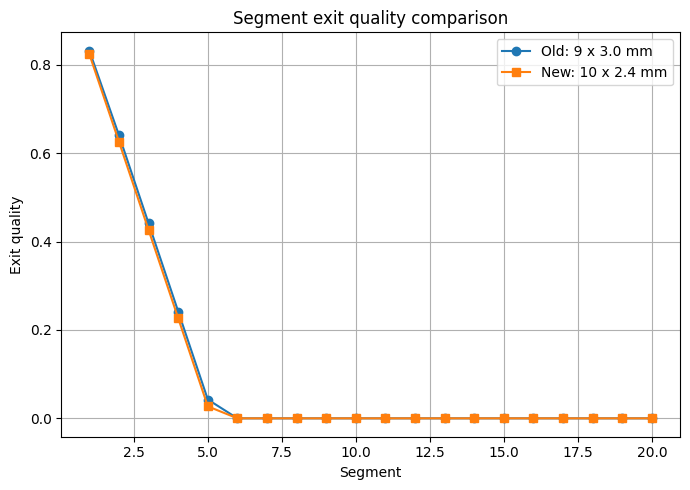

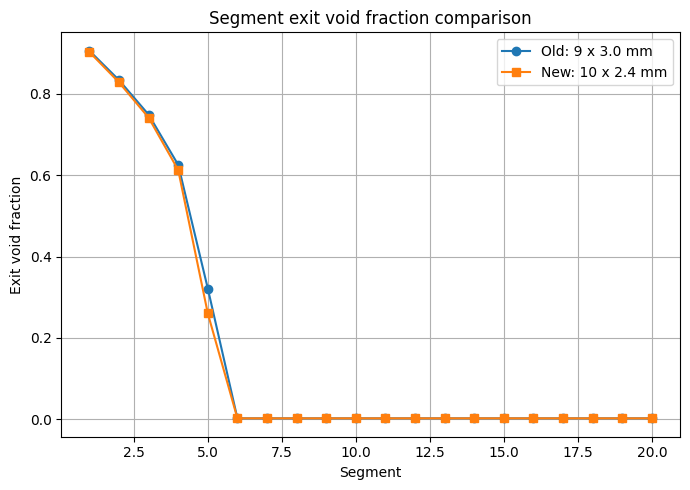

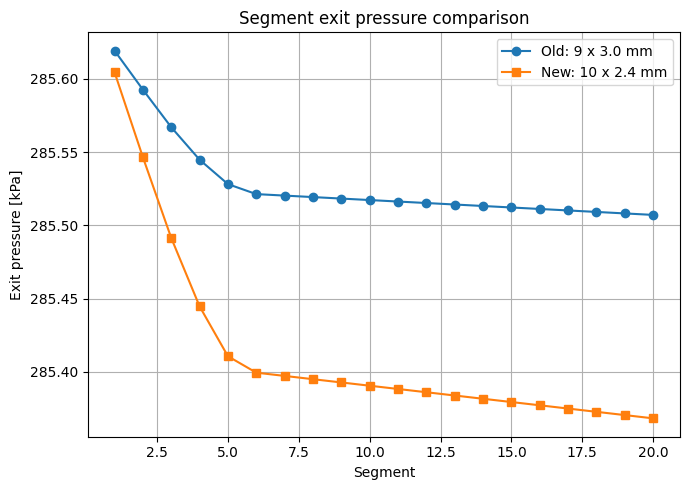

In [ ]:
#TASK 3A (new configuration/design)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# GIVEN / BASE CONDITIONS
# ============================================================

q_chip = 340.0          # W
Ta_in_C = 20.0          # C
Va = 6.5                # m/s
dz = 0.040              # m
segments_count = 20
rho_a = 1.3             # kg/m^3
cp_a = 1005.0           # J/kg-K
Lf = 5.26e-3            # m
g = 9.81                # m/s^2

A_chip = (6e-2)**2      # m^2
theta = 35 * np.pi / 180.0
q_double_dot = q_chip / A_chip
T_design_chip = 55.0 + 273.15   # K

# inlet state to condenser
x_s0 = 0.999
alpha_s0 = 0.999

# Use the SAME evaporator pressure from Task 2
P_design = 285.63   # kPa  # Task 2 design evaporator pressure

# ============================================================
# SATURATION PROPERTY MODEL
# ============================================================

C0 = 20.472
C1 = -2579.9

T_data_C = np.array([15.1, 30.0, 46.0, 60.0])
rho_l_data = np.array([1365.0, 1325.0, 1279.0, 1267.0])      # kg/m^3
rho_v_data = np.array([5.961, 10.169, 17.30, 25.68])         # kg/m^3
mu_l_data  = np.array([464e-6, 382e-6, 314e-6, 266e-6])      # Pa·s
mu_v_data  = np.array([9.93e-6, 10.4e-6, 11.0e-6, 11.5e-6])  # Pa·s
k_l_data   = np.array([0.0912, 0.0865, 0.0814, 0.0769])      # W/m·K
h_lv_data  = np.array([196.1e3, 187.0e3, 177.2e3, 168.0e3])  # J/kg
sigma_data = np.array([0.0153, 0.0134, 0.0114, 0.0096])      # N/m
cp_l_data  = np.array([1318.0, 1350.0, 1388.0, 1428.0])      # J/kg·K

def lagrange_interp(x, xdata, ydata):
    n = len(xdata)
    y = 0.0
    for i in range(n):
        Li = 1.0
        for j in range(n):
            if i != j:
                Li *= (x - xdata[j]) / (xdata[i] - xdata[j])
        y += ydata[i] * Li
    return y

def Tsat_from_P(P_kPa):
    P_Pa = P_kPa * 1000.0
    return C1 / (np.log(P_Pa) - C0)

def r245fa_sat_props(P_kPa):
    Tsat_K = Tsat_from_P(P_kPa)
    Tsat_C = Tsat_K - 273.15

    rho_l = lagrange_interp(Tsat_C, T_data_C, rho_l_data)
    rho_v = lagrange_interp(Tsat_C, T_data_C, rho_v_data)
    mu_l  = lagrange_interp(Tsat_C, T_data_C, mu_l_data)
    mu_v  = lagrange_interp(Tsat_C, T_data_C, mu_v_data)
    k_l   = lagrange_interp(Tsat_C, T_data_C, k_l_data)
    h_lv  = lagrange_interp(Tsat_C, T_data_C, h_lv_data)
    sigma = lagrange_interp(Tsat_C, T_data_C, sigma_data)
    cp_l  = lagrange_interp(Tsat_C, T_data_C, cp_l_data)

    Pr_l = mu_l * cp_l / k_l

    return {
        "Tsat_K": Tsat_K,
        "Tsat_C": Tsat_C,
        "rho_l": rho_l,
        "rho_v": rho_v,
        "mu_l": mu_l,
        "mu_v": mu_v,
        "k_l": k_l,
        "h_lv": h_lv,
        "sigma": sigma,
        "cp_l": cp_l,
        "Pr_l": Pr_l
    }

# ============================================================
# SEGMENT MODEL
# ============================================================

def segment_model(
    q_chip=340.0,
    Ta_in_C=20.0,
    Va=6.5,
    P_in_kPa=220,
    dz=0.040,
    D=0.003,
    n_tubes=9,
    x_in=0.999,
    rho_a=1.3,
    cp_a=1005.0,
    Lf=5.26e-3,
    g=9.81
):
    props = r245fa_sat_props(P_in_kPa)

    Tsat_K = props["Tsat_K"]
    rho_l = props["rho_l"]
    rho_v = props["rho_v"]
    mu_l = props["mu_l"]
    mu_v = props["mu_v"]
    k_l = props["k_l"]
    h_lv = props["h_lv"]
    sigma = props["sigma"]
    Pr_l = props["Pr_l"]

    Ta_in_K = Ta_in_C + 273.15

    # Flow area and mass flux
    A_passage = np.pi * D**2 / 4.0
    A_total = n_tubes * A_passage
    G = q_chip / (A_total * h_lv)

    # Reynolds numbers
    Re_lo = G * D / mu_l
    Re_l = G * (1.0 - x_in) * D / mu_l
    Re_vo = G * D / mu_v

    # Guard against zero / invalid values
    x_safe = max(x_in, 1.0e-6)
    one_minus_x_safe = max(1.0 - x_in, 1.0e-6)
    Re_l_safe = max(Re_l, 1.0e-6)

    # Martinelli parameter
    X_tt = ((one_minus_x_safe / x_safe)**0.9) * (rho_v / rho_l)**0.5 * (mu_l / mu_v)**0.1
    X_tt = max(X_tt, 1.0e-8)

    # Traviss factor
    if Re_l > 1125:
        F_T = 0.812 * (Pr_l**0.5) + 5.0 * np.log(1.0 + 5.0 * Pr_l) + 2.5 * np.log(0.0031 * Re_l_safe)
    elif Re_l > 50:
        F_T = 0.585 * (Pr_l**0.5) + 5.0 * np.log(1.0 + Pr_l * (0.0964 * Re_l_safe**0.585 - 1.0))
    else:
        F_T = 0.5 * (Pr_l**0.5) * Re_l_safe

    # Refrigerant-side h
    hr = (k_l / D) * 0.15 * (Pr_l**0.4) * (Re_l_safe**0.9) * F_T * (1.0 / X_tt + 2.85 / X_tt**0.476)

    # Void fraction at inlet
    alpha_in = 1.0 / (
        1.0
        + ((one_minus_x_safe / x_safe)**0.64)
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # UA and segment heat transfer
    Ar = n_tubes * np.pi * D * dz
    UA_air = 77.1 * (Va / 6.5)**0.5 * dz
    UA_seg = 1.0 / (1.0 / (hr * Ar) + 1.0 / UA_air)

    m_dot_a_seg = rho_a * Va * (2.0 * Lf) * dz
    C_a_seg = m_dot_a_seg * cp_a
    NTU = UA_seg / C_a_seg
    eps_seg = 1.0 - np.exp(-NTU)

    q_seg = C_a_seg * (Tsat_K - Ta_in_K) * eps_seg

    # Exit quality
    x_out = x_in - q_seg / q_chip
    if x_out < 0.0:
        x_out = 1.0e-5
        q_seg = (x_in - x_out) * q_chip

    x_out_safe = max(x_out, 1.0e-6)
    one_minus_x_out_safe = max(1.0 - x_out, 1.0e-6)

    # Exit void fraction
    alpha_out = 1.0 / (
        1.0
        + ((one_minus_x_out_safe / x_out_safe)**0.64)
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Pressure drop model
    Gamma_in = G**2 * (
        x_safe**2 / (rho_v * alpha_in)
        + one_minus_x_safe**2 / (rho_l * (1.0 - alpha_in))
    )

    Gamma_out = G**2 * (
        x_out_safe**2 / (rho_v * alpha_out)
        + one_minus_x_out_safe**2 / (rho_l * (1.0 - alpha_out))
    )

    f_lo = 16.0 / max(Re_lo, 1.0e-6)
    dPdz_lo = 2.0 * G**2 * f_lo / (D * rho_l)

    if Re_vo < 2300.0:
        f_vo = 16.0 / max(Re_vo, 1.0e-6)
    else:
        f_vo = 0.079 * Re_vo**(-0.25)

    rho_tp = 1.0 / (x_safe / rho_v + one_minus_x_safe / rho_l)
    Fr = G**2 / (rho_tp**2 * g * D)
    We = G**2 * D / (rho_tp * sigma)

    E = one_minus_x_safe**2 + x_safe**2 * (rho_l * f_vo) / (rho_v * f_lo)
    F = x_safe**0.78 * one_minus_x_safe**0.224
    H = (rho_l / rho_v)**0.91 * (mu_v / mu_l)**0.19 * (1.0 - mu_v / mu_l)**0.7

    phi_lo_sq = E + 3.24 * F * H / (Fr**0.045 * We**0.035)

    P_out_Pa = P_in_kPa * 1000.0 - phi_lo_sq * dPdz_lo * dz - (Gamma_out - Gamma_in)
    P_out_kPa = P_out_Pa / 1000.0

    return {
        "Tsat_C": props["Tsat_C"],
        "G": G,
        "hr": hr,
        "UA_seg": UA_seg,
        "q_seg": q_seg,
        "x_out": x_out,
        "alpha_in": alpha_in,
        "alpha_out": alpha_out,
        "phi_lo_sq": phi_lo_sq,
        "P_out_kPa": P_out_kPa
    }

# ============================================================
# CONDENSER LOOP MODEL
# ============================================================

def condenser_sim(q_chip, Ta_in_C, Va, P_design, dz, D, n_tubes, segments_count, rho_a, cp_a, Lf, g):
    x = x_s0
    P_kPa = P_design

    records = []
    q_total = 0.0

    for i in range(segments_count):
        res = segment_model(
            q_chip=q_chip,
            Ta_in_C=Ta_in_C,
            Va=Va,
            P_in_kPa=P_kPa,
            dz=dz,
            D=D,
            n_tubes=n_tubes,
            x_in=x,
            rho_a=rho_a,
            cp_a=cp_a,
            Lf=Lf,
            g=g
        )

        record = {
            "Segment": i + 1,
            "x_out": res["x_out"],
            "alpha_out": res["alpha_out"],
            "P_out_kPa": res["P_out_kPa"],
            "q_seg_W": res["q_seg"],
            "hr_W_m2K": res["hr"],
            "G_kg_m2s": res["G"]
        }
        records.append(record)

        x = res["x_out"]
        P_kPa = res["P_out_kPa"]
        q_total += res["q_seg"]

    dP_total = P_design - P_kPa

    return {
        "records": pd.DataFrame(records),
        "q_total_W": q_total,
        "dP_total_kPa": dP_total,
        "P_exit_kPa": P_kPa,
        "x_exit": x,
        "alpha_exit": records[-1]["alpha_out"]
    }

# ============================================================
# RUN BASE CASE (TASK 2) AND NEW CASE (TASK 3a)
# ============================================================

# Original Task 2 geometry
D_old = 0.0030
n_tubes_old = 9

# New Task 3(a) geometry
D_new = 0.0024
n_tubes_new = 10

old_case = condenser_sim(
    q_chip, Ta_in_C, Va, P_design, dz, D_old, n_tubes_old,
    segments_count, rho_a, cp_a, Lf, g
)

new_case = condenser_sim(
    q_chip, Ta_in_C, Va, P_design, dz, D_new, n_tubes_new,
    segments_count, rho_a, cp_a, Lf, g
)

# ============================================================
# BUILD COMPARISON TABLE
# ============================================================

df_old = old_case["records"].copy()
df_new = new_case["records"].copy()

comparison = pd.DataFrame({
    "Segment": df_old["Segment"],
    "x_out_old": df_old["x_out"],
    "x_out_new": df_new["x_out"],
    "alpha_out_old": df_old["alpha_out"],
    "alpha_out_new": df_new["alpha_out"],
    "P_out_old_kPa": df_old["P_out_kPa"],
    "P_out_new_kPa": df_new["P_out_kPa"],
    "q_seg_old_W": df_old["q_seg_W"],
    "q_seg_new_W": df_new["q_seg_W"]
})

pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: f"{x:0.5f}")

print("\n==================== TASK 3(a): SEGMENT-BY-SEGMENT COMPARISON ====================\n")
print(comparison.to_string(index=False))

# ============================================================
# OVERALL RESULTS
# ============================================================

print("\n==================== OVERALL CONDENSER RESULTS ====================\n")

print("Original Task 2 geometry: 9 passages, D = 3.0 mm")
print(f"  Total condenser heat transfer = {old_case['q_total_W']:.3f} W")
print(f"  Total condenser pressure drop = {old_case['dP_total_kPa']:.5f} kPa")
print(f"  Condenser exit pressure       = {old_case['P_exit_kPa']:.5f} kPa")
print(f"  Condenser exit quality        = {old_case['x_exit']:.6f}")
print(f"  Condenser exit void fraction  = {old_case['alpha_exit']:.6f}\n")

print("New Task 3(a) geometry: 10 passages, D = 2.4 mm")
print(f"  Total condenser heat transfer = {new_case['q_total_W']:.3f} W")
print(f"  Total condenser pressure drop = {new_case['dP_total_kPa']:.5f} kPa")
print(f"  Condenser exit pressure       = {new_case['P_exit_kPa']:.5f} kPa")
print(f"  Condenser exit quality        = {new_case['x_exit']:.6f}")
print(f"  Condenser exit void fraction  = {new_case['alpha_exit']:.6f}\n")

print("==================== DIFFERENCE: NEW - OLD ====================\n")
print(f"Delta total heat transfer = {new_case['q_total_W'] - old_case['q_total_W']:.3f} W")
print(f"Delta total pressure drop = {new_case['dP_total_kPa'] - old_case['dP_total_kPa']:.5f} kPa")
print(f"Delta exit quality        = {new_case['x_exit'] - old_case['x_exit']:.6f}")
print(f"Delta exit pressure       = {new_case['P_exit_kPa'] - old_case['P_exit_kPa']:.5f} kPa")

# ============================================================
# OPTIONAL PLOTS FOR REPORT
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(comparison["Segment"], comparison["x_out_old"], 'o-', label="Old: 9 x 3.0 mm")
plt.plot(comparison["Segment"], comparison["x_out_new"], 's-', label="New: 10 x 2.4 mm")
plt.xlabel("Segment")
plt.ylabel("Exit quality")
plt.title("Segment exit quality comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(comparison["Segment"], comparison["alpha_out_old"], 'o-', label="Old: 9 x 3.0 mm")
plt.plot(comparison["Segment"], comparison["alpha_out_new"], 's-', label="New: 10 x 2.4 mm")
plt.xlabel("Segment")
plt.ylabel("Exit void fraction")
plt.title("Segment exit void fraction comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(comparison["Segment"], comparison["P_out_old_kPa"], 'o-', label="Old: 9 x 3.0 mm")
plt.plot(comparison["Segment"], comparison["P_out_new_kPa"], 's-', label="New: 10 x 2.4 mm")
plt.xlabel("Segment")
plt.ylabel("Exit pressure [kPa]")
plt.title("Segment exit pressure comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Task 3(b) - Condenser length for complete condensation

def segment_model_no_clip(
    q_chip=340.0,
    Ta_in_C=20.0,
    Va=6.5,
    P_in_kPa=285.63,
    dz=0.040,
    D=0.0024,
    n_tubes=10,
    x_in=0.999,
    rho_a=1.3,
    cp_a=1005.0,
    Lf=5.26e-3,
    g=9.81
):
    """
    Same as your segment model, but keeps the 'raw' x_out before clipping,
    so we can detect where x crosses zero inside a segment.
    """
    props = r245fa_sat_props(P_in_kPa)

    Tsat_K = props["Tsat_K"]
    rho_l = props["rho_l"]
    rho_v = props["rho_v"]
    mu_l = props["mu_l"]
    mu_v = props["mu_v"]
    k_l = props["k_l"]
    h_lv = props["h_lv"]
    sigma = props["sigma"]
    Pr_l = props["Pr_l"]

    Ta_in_K = Ta_in_C + 273.15

    # Flow area and mass flux
    A_passage = np.pi * D**2 / 4.0
    A_total = n_tubes * A_passage
    G = q_chip / (A_total * h_lv)

    # Reynolds numbers
    Re_lo = G * D / mu_l
    Re_l = G * max(1.0 - x_in, 1.0e-8) * D / mu_l
    Re_vo = G * D / mu_v

    x_safe = max(x_in, 1.0e-8)
    one_minus_x_safe = max(1.0 - x_in, 1.0e-8)

    # Martinelli parameter
    X_tt = ((one_minus_x_safe / x_safe)**0.9) * (rho_v / rho_l)**0.5 * (mu_l / mu_v)**0.1
    X_tt = max(X_tt, 1.0e-8)

    # Traviss factor
    if Re_l > 1125:
        F_T = 0.812 * (Pr_l**0.5) + 5.0 * np.log(1.0 + 5.0 * Pr_l) + 2.5 * np.log(0.0031 * Re_l)
    elif Re_l > 50:
        F_T = 0.585 * (Pr_l**0.5) + 5.0 * np.log(1.0 + Pr_l * (0.0964 * Re_l**0.585 - 1.0))
    else:
        F_T = 0.5 * (Pr_l**0.5) * Re_l

    # Refrigerant-side heat transfer coefficient
    hr = (k_l / D) * 0.15 * (Pr_l**0.4) * (Re_l**0.9) * F_T * (1.0 / X_tt + 2.85 / X_tt**0.476)

    # Inlet void fraction
    alpha_in = 1.0 / (
        1.0
        + ((one_minus_x_safe / x_safe)**0.64)
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # UA and heat transfer
    Ar = n_tubes * np.pi * D * dz
    UA_air = 77.1 * (Va / 6.5)**0.5 * dz
    UA_seg = 1.0 / (1.0 / (hr * Ar) + 1.0 / UA_air)

    m_dot_a_seg = rho_a * Va * (2.0 * Lf) * dz
    C_a_seg = m_dot_a_seg * cp_a
    NTU = UA_seg / C_a_seg
    eps_seg = 1.0 - np.exp(-NTU)

    q_seg = C_a_seg * (Tsat_K - Ta_in_K) * eps_seg

    # raw exit quality before clipping
    x_out_raw = x_in - q_seg / q_chip

    # clipped value only for pressure-drop calculation stability
    if x_out_raw <= 0.0:
        x_out_clip = 1.0e-8
        q_seg_effective = x_in * q_chip   # only enough to reach x = 0
    else:
        x_out_clip = x_out_raw
        q_seg_effective = q_seg

    # Exit void fraction
    x_out_safe = max(x_out_clip, 1.0e-8)
    one_minus_x_out_safe = max(1.0 - x_out_clip, 1.0e-8)

    alpha_out = 1.0 / (
        1.0
        + ((one_minus_x_out_safe / x_out_safe)**0.64)
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Pressure drop model
    Gamma_in = G**2 * (
        x_safe**2 / (rho_v * alpha_in)
        + one_minus_x_safe**2 / (rho_l * (1.0 - alpha_in))
    )

    Gamma_out = G**2 * (
        x_out_safe**2 / (rho_v * alpha_out)
        + one_minus_x_out_safe**2 / (rho_l * (1.0 - alpha_out))
    )

    f_lo = 16.0 / max(Re_lo, 1.0e-8)
    dPdz_lo = 2.0 * G**2 * f_lo / (D * rho_l)

    if Re_vo < 2300.0:
        f_vo = 16.0 / max(Re_vo, 1.0e-8)
    else:
        f_vo = 0.079 * Re_vo**(-0.25)

    rho_tp = 1.0 / (x_safe / rho_v + one_minus_x_safe / rho_l)
    Fr = G**2 / (rho_tp**2 * g * D)
    We = G**2 * D / (rho_tp * sigma)

    E = one_minus_x_safe**2 + x_safe**2 * (rho_l * f_vo) / (rho_v * f_lo)
    F = x_safe**0.78 * one_minus_x_safe**0.224
    H = (rho_l / rho_v)**0.91 * (mu_v / mu_l)**0.19 * (1.0 - mu_v / mu_l)**0.7

    phi_lo_sq = E + 3.24 * F * H / (Fr**0.045 * We**0.035)

    P_out_Pa = P_in_kPa * 1000.0 - phi_lo_sq * dPdz_lo * dz - (Gamma_out - Gamma_in)
    P_out_kPa = P_out_Pa / 1000.0

    return {
        "q_seg": q_seg,
        "q_seg_effective": q_seg_effective,
        "x_out_raw": x_out_raw,
        "x_out_clip": x_out_clip,
        "alpha_out": alpha_out,
        "P_out_kPa": P_out_kPa,
        "UA_seg": UA_seg,
        "hr": hr
    }


def find_required_condenser_length(
    P_design = 285.63,   # kPa  # Task 2 design evaporator pressure
    q_chip=340.0,
    Ta_in_C=20.0,
    Va=6.5,
    dz_base=0.040,
    D=0.0024,
    n_tubes=10,
    rho_a=1.3,
    cp_a=1005.0,
    Lf=5.26e-3,
    g=9.81,
    x_start=0.999,
    max_segments=200
):
    """
    Finds the tube length required so that x reaches exactly 0 at the outlet.
    Uses linear interpolation within the crossing segment.
    """
    x = x_start
    P_kPa = P_design
    total_length = 0.0
    total_heat = 0.0
    records = []

    for i in range(max_segments):
        res = segment_model_no_clip(
            q_chip=q_chip,
            Ta_in_C=Ta_in_C,
            Va=Va,
            P_in_kPa=P_kPa,
            dz=dz_base,
            D=D,
            n_tubes=n_tubes,
            x_in=x,
            rho_a=rho_a,
            cp_a=cp_a,
            Lf=Lf,
            g=g
        )

        x_out_raw = res["x_out_raw"]

        # Case 1: condensation finishes inside this segment
        if x_out_raw <= 0.0:
            # fraction of this segment needed to go from x_in to x=0
            frac = x / (x - x_out_raw)
            dz_needed = frac * dz_base
            total_length += dz_needed

            # heat needed to reach x = 0 exactly
            q_needed = x * q_chip
            total_heat += q_needed

            records.append({
                "segment": i + 1,
                "x_in": x,
                "x_out_est": 0.0,
                "P_in_kPa": P_kPa,
                "P_out_kPa_est": np.nan,   # pressure at interpolated partial segment not estimated exactly
                "dz_used_m": dz_needed,
                "crossed_zero": True
            })

            return {
                "required_length_m": total_length,
                "required_length_cm": total_length * 100.0,
                "segments_used": i + frac,
                "full_segments_completed": i,
                "heat_removed_W": total_heat,
                "records": pd.DataFrame(records)
            }

        # Case 2: still two-phase after full segment
        total_length += dz_base
        total_heat += res["q_seg"]

        records.append({
            "segment": i + 1,
            "x_in": x,
            "x_out_est": x_out_raw,
            "P_in_kPa": P_kPa,
            "P_out_kPa_est": res["P_out_kPa"],
            "dz_used_m": dz_base,
            "crossed_zero": False
        })

        x = x_out_raw
        P_kPa = res["P_out_kPa"]

    raise RuntimeError("Did not reach x = 0 within max_segments. Increase max_segments.")


# ============================================================
# RUN TASK 3(b)
# ============================================================

P_design = 285.63   # kPa

result_b = find_required_condenser_length(
    P_design=P_design,
    q_chip=340.0,
    Ta_in_C=20.0,
    Va=6.5,
    dz_base=0.040,
    D=0.0024,
    n_tubes=10,
    rho_a=1.3,
    cp_a=1005.0,
    Lf=5.26e-3,
    g=9.81,
    x_start=0.999
)

print("\n================ TASK 3(b) RESULT ================\n")
print(f"Required condenser tube length for x_out = 0: {result_b['required_length_m']:.6f} m")
print(f"Required condenser tube length for x_out = 0: {result_b['required_length_cm']:.3f} cm")
print(f"Equivalent number of 0.040 m segments: {result_b['segments_used']:.3f}")

print("\nSegment history up to condensation completion:\n")
print(result_b["records"].to_string(index=False))


================ TASK 3(b) RESULT ================

Required condenser tube length for x_out = 0: 0.205504 m
Required condenser tube length for x_out = 0: 20.550 cm
Equivalent number of 0.040 m segments: 5.138

Segment history up to condensation completion:

 segment    x_in  x_out_est  P_in_kPa  P_out_kPa_est  dz_used_m  crossed_zero
       1 0.99900    0.82342 285.63000      285.60453    0.04000         False
       2 0.82342    0.62552 285.60453      285.54650    0.04000         False
       3 0.62552    0.42600 285.54650      285.49141    0.04000         False
       4 0.42600    0.22645 285.49141      285.44472    0.04000         False
       5 0.22645    0.02715 285.44472      285.41067    0.04000         False
       6 0.02715    0.00000 285.41067            NaN    0.00550          True


In [ ]:
#TASK 3(c)

import numpy as np
import pandas as pd

# ============================================================
# TASK 3(c)
# New geometry from Task 3(a): 10 passages, D = 2.4 mm
# Length from Task 3(b): choose exactly the value you found
# Air inlet temperature now = 25 C
# Search for one or more modifications that satisfy:
#   - outlet saturated liquid (x_exit ~ 0)
#   - chip temperature < 55 C
# ============================================================

# -----------------------------
# USER INPUTS
# -----------------------------
P_task2 = 285.63   # kPa (Task 2 design pressure)
L_task3b = 0.205504             # <-- Task 3(b) result [m]
Ta_in_new_C = 25.0              # new inlet air temperature for Task 3(c)

# fixed condenser geometry from Task 3(a)/(b)
D_new = 0.0024                  # m
n_tubes_new = 10

# other given conditions
q_chip = 340.0                  # W
Va_base = 6.5                   # m/s
rho_a = 1.3                     # kg/m^3
cp_a = 1005.0                   # J/kg-K
Lf = 5.26e-3                    # m
g = 9.81                        # m/s^2
dz_base = 0.040                 # m
x_s0 = 0.999                    # inlet quality to condenser
A_chip = (6e-2)**2              # m^2
theta = 35 * np.pi / 180.0
q_double_dot = q_chip / A_chip
T_chip_target_C = 55.0

# ------------------------------------------------------------
# CHIP TEMPERATURE MODEL (from Task 1 )
# ------------------------------------------------------------
def chip_temperature_from_pressure(P_kPa):
    """
    Returns predicted chip/wall temperature in deg C
    using the same boiling-side relation used in the earlier code.
    """
    props = r245fa_sat_props(P_kPa)

    Tsat = props["Tsat_K"]
    rho_l = props["rho_l"]
    rho_v = props["rho_v"]
    k_l = props["k_l"]
    Pr_l = props["Pr_l"]
    sigma = props["sigma"]

    Db = 0.0208 * theta * np.sqrt(sigma / (g * (rho_l - rho_v)))
    B = ((rho_v / rho_l)**0.581) * (Pr_l**0.533)

    # same expression structure as your Task 2 code
    T_wall_K = (1/207) * (q_double_dot * Db / k_l) * ((k_l * Tsat / (q_double_dot * Db))**0.745) * (B**(-1)) + Tsat
    T_wall_C = T_wall_K - 273.15

    return T_wall_C


# ------------------------------------------------------------
# CONDENSER SIMULATION FOR ARBITRARY TOTAL LENGTH
# Allows final partial segment
# ------------------------------------------------------------
def condenser_sim_variable_length(
    total_length_m,
    q_chip=340.0,
    Ta_in_C=25.0,
    Va=6.5,
    P_design = 285.63,   # kPa (Task 2 design pressure),
    dz_base=0.040,
    D=0.0024,
    n_tubes=10,
    rho_a=1.3,
    cp_a=1005.0,
    Lf=5.26e-3,
    g=9.81,
    x_start=0.999
):
    x = x_start
    P_kPa = P_design
    q_total = 0.0
    z_total = 0.0
    records = []

    n_full = int(total_length_m // dz_base)
    dz_last = total_length_m - n_full * dz_base

    segment_lengths = [dz_base] * n_full
    if dz_last > 1e-12:
        segment_lengths.append(dz_last)

    for i, dz_i in enumerate(segment_lengths):
        res = segment_model_no_clip(
            q_chip=q_chip,
            Ta_in_C=Ta_in_C,
            Va=Va,
            P_in_kPa=P_kPa,
            dz=dz_i,
            D=D,
            n_tubes=n_tubes,
            x_in=x,
            rho_a=rho_a,
            cp_a=cp_a,
            Lf=Lf,
            g=g
        )

        x_out_raw = res["x_out_raw"]

        # if condensation completes inside this segment
        if x_out_raw <= 0.0:
            frac = x / (x - x_out_raw)
            dz_used = frac * dz_i
            q_needed = x * q_chip

            z_total += dz_used
            q_total += q_needed

            records.append({
                "segment": i + 1,
                "dz_m": dz_used,
                "x_in": x,
                "x_out": 0.0,
                "P_in_kPa": P_kPa,
                "P_out_kPa": np.nan,
                "crossed_zero": True
            })

            return {
                "records": pd.DataFrame(records),
                "q_total_W": q_total,
                "P_exit_kPa": P_kPa,        # approximate, since final partial-segment P not interpolated
                "x_exit": 0.0,
                "alpha_exit": 0.0,
                "used_length_m": z_total,
                "fully_condensed": True
            }

        # otherwise complete full/partial segment normally
        z_total += dz_i
        q_total += res["q_seg"]

        records.append({
            "segment": i + 1,
            "dz_m": dz_i,
            "x_in": x,
            "x_out": x_out_raw,
            "P_in_kPa": P_kPa,
            "P_out_kPa": res["P_out_kPa"],
            "crossed_zero": False
        })

        x = x_out_raw
        P_kPa = res["P_out_kPa"]

    # did not fully condense within total_length_m
    # estimate exit void fraction using small-quality clipping
    x_safe = max(x, 1.0e-8)
    props = r245fa_sat_props(P_kPa)
    rho_l = props["rho_l"]
    rho_v = props["rho_v"]
    mu_l = props["mu_l"]
    mu_v = props["mu_v"]

    alpha_exit = 1.0 / (
        1.0
        + ((max(1.0 - x_safe, 1.0e-8) / x_safe)**0.64)
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    return {
        "records": pd.DataFrame(records),
        "q_total_W": q_total,
        "P_exit_kPa": P_kPa,
        "x_exit": x,
        "alpha_exit": alpha_exit,
        "used_length_m": z_total,
        "fully_condensed": False
    }


# ------------------------------------------------------------
# BASELINE TASK 3 SYSTEM AT 25 C
# ------------------------------------------------------------
baseline_case = condenser_sim_variable_length(
    total_length_m=L_task3b,
    q_chip=q_chip,
    Ta_in_C=Ta_in_new_C,
    Va=Va_base,
    P_design=P_task2,
    dz_base=dz_base,
    D=D_new,
    n_tubes=n_tubes_new,
    rho_a=rho_a,
    cp_a=cp_a,
    Lf=Lf,
    g=g,
    x_start=x_s0
)

baseline_Tchip_C = chip_temperature_from_pressure(P_task2)

print("\n================ BASELINE TASK 3 SYSTEM @ Ta,in = 25 C ================\n")
print(f"P_ev [kPa]              = {P_task2:.3f}")
print(f"Va [m/s]                = {Va_base:.3f}")
print(f"Tube length [m]         = {L_task3b:.6f}")
print(f"Outlet quality [-]      = {baseline_case['x_exit']:.6f}")
print(f"Outlet pressure [kPa]   = {baseline_case['P_exit_kPa']:.6f}")
print(f"Total heat transfer [W] = {baseline_case['q_total_W']:.6f}")
print(f"Predicted chip temp [C] = {baseline_Tchip_C:.6f}")
print(f"Fully condensed?        = {baseline_case['fully_condensed']}")


# ------------------------------------------------------------
# SEARCH FOR FEASIBLE MODIFICATIONS (ranges can be changed)
# ------------------------------------------------------------
P_candidates = np.arange(260.0, 321.0, 5.0)     # kPa
Va_candidates = np.arange(6.5, 13.1, 0.5)       # m/s
L_candidates = np.arange(L_task3b, 0.801, 0.01) # m

solutions = []

for P_try in P_candidates:
    Tchip_try = chip_temperature_from_pressure(P_try)

    # chip must stay below 55 C
    if Tchip_try >= T_chip_target_C:
        continue

    for Va_try in Va_candidates:
        for L_try in L_candidates:
            sim = condenser_sim_variable_length(
                total_length_m=L_try,
                q_chip=q_chip,
                Ta_in_C=Ta_in_new_C,
                Va=Va_try,
                P_design=P_try,
                dz_base=dz_base,
                D=D_new,
                n_tubes=n_tubes_new,
                rho_a=rho_a,
                cp_a=cp_a,
                Lf=Lf,
                g=g,
                x_start=x_s0
            )

            # criterion: outlet saturated liquid
            if sim["x_exit"] <= 1e-4:
                # score = smallest overall deviation from baseline system
                score = (
                    abs(P_try - P_task2) / P_task2
                    + abs(Va_try - Va_base) / Va_base
                    + abs(L_try - L_task3b) / L_task3b
                )

                solutions.append({
                    "P_ev_kPa": P_try,
                    "Va_m_s": Va_try,
                    "Tube_length_m": L_try,
                    "Tube_length_cm": 100.0 * L_try,
                    "Outlet_pressure_kPa": sim["P_exit_kPa"],
                    "Outlet_quality": sim["x_exit"],
                    "Outlet_void_fraction": sim["alpha_exit"],
                    "Total_heat_transfer_W": sim["q_total_W"],
                    "Chip_temperature_C": Tchip_try,
                    "Fully_condensed": sim["fully_condensed"],
                    "Score": score
                })

# ------------------------------------------------------------
# RESULTS OF SEARCH
# ------------------------------------------------------------
if len(solutions) == 0:
    print("\nNo feasible modified design found in the search range.")
else:
    solutions_df = pd.DataFrame(solutions).sort_values("Score").reset_index(drop=True)

    print("\n================ FEASIBLE MODIFIED SYSTEMS ================\n")
    print(solutions_df.head(10).to_string(index=False))

    # choose best / least-modified feasible design
    best = solutions_df.iloc[0]

    # comparison table requested in Task 3(c)
    comparison_table = pd.DataFrame({
        "Quantity": [
            "Evaporator pressure [kPa]",
            "Air velocity [m/s]",
            "Tube length [m]",
            "Tube length [cm]",
            "Inlet air temperature [C]",
            "Outlet pressure [kPa]",
            "Outlet quality [-]",
            "Outlet void fraction [-]",
            "Total heat transfer to air [W]",
            "Predicted chip temperature [C]"
        ],
        "Task 3 system @ 25 C": [
            P_task2,
            Va_base,
            L_task3b,
            100.0 * L_task3b,
            Ta_in_new_C,
            baseline_case["P_exit_kPa"],
            baseline_case["x_exit"],
            baseline_case["alpha_exit"],
            baseline_case["q_total_W"],
            baseline_Tchip_C
        ],
        "Altered feasible system": [
            best["P_ev_kPa"],
            best["Va_m_s"],
            best["Tube_length_m"],
            best["Tube_length_cm"],
            Ta_in_new_C,
            best["Outlet_pressure_kPa"],
            best["Outlet_quality"],
            best["Outlet_void_fraction"],
            best["Total_heat_transfer_W"],
            best["Chip_temperature_C"]
        ]
    })

    print("\n================ TASK 3(c): COMPARISON TABLE ================\n")
    print(comparison_table.to_string(index=False))

    # save tables if needed
    solutions_df.to_csv("task3c_feasible_solutions.csv", index=False)
    comparison_table.to_csv("task3c_comparison_table.csv", index=False)


================ BASELINE TASK 3 SYSTEM @ Ta,in = 25 C ================

P_ev [kPa]              = 285.630
Va [m/s]                = 6.500
Tube length [m]         = 0.205504
Outlet quality [-]      = 0.154904
Outlet pressure [kPa]   = 285.379219
Total heat transfer [W] = 286.992556
Predicted chip temp [C] = 56.202567
Fully condensed?        = False

================ FEASIBLE MODIFIED SYSTEMS ================

 P_ev_kPa  Va_m_s  Tube_length_m  Tube_length_cm  Outlet_pressure_kPa  Outlet_quality  Outlet_void_fraction  Total_heat_transfer_W  Chip_temperature_C  Fully_condensed   Score
270.00000 7.00000        0.23550        23.55040            269.75580         0.00000               0.00000              339.66000            53.98786             True 0.27763
275.00000 6.50000        0.25550        25.55040            274.69861         0.00000               0.00000              339.66000            54.70587             True 0.28052
270.00000 7.00000        0.24550        24.55040          

**Task 4 Below**

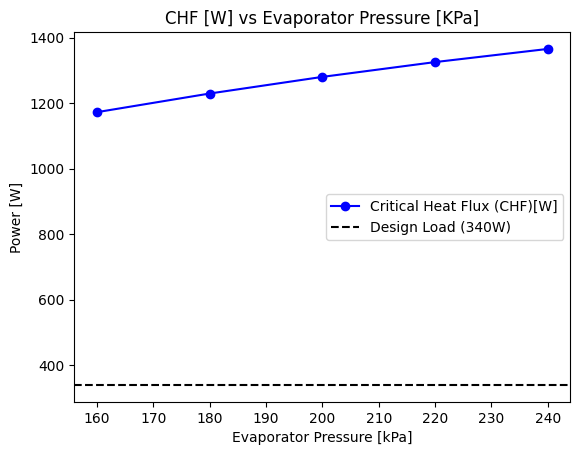

The CHF corresponding to the Design Pressure (W): 1441.315
Chip Temperature at CHF [C] : [53.02566731]

[Part b] Case 1 Condenser Simulation Results
 Seg    x_out    α_out P_out (kPa)  q_seg (W)
   1  0.92802  0.94689     285.5423   102.3061
   2  0.85592  0.91568     285.4270   103.9227
   3  0.78375  0.88785     285.3162   104.0131
   4  0.71160  0.86093     285.2127   103.9969
   5  0.63947  0.83368     285.1174   103.9643
   6  0.56736  0.80515     285.0306   103.9270
   7  0.49528  0.77441     284.9524   103.8887
   8  0.42323  0.74028     284.8824   103.8502
   9  0.35120  0.70116     284.8204   103.8117
  10  0.27920  0.65447     284.7663   103.7721
  11  0.20724  0.59559     284.7199   103.7295
  12  0.13530  0.51468     284.6814   103.6792
  13  0.06338  0.38280     284.6517   103.6604
  14  0.00001  0.00219     284.6334    91.3376
  15  0.00001  0.00219     284.6291     0.0000
  16  0.00001  0.00219     284.6248     0.0000
  17  0.00001  0.00219     284.6205     0.0000
  18  

In [71]:
''' Task 4 '''

import numpy as np
import math
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as P

#define the five evaporator pressures (P2)
P2_vals = [160.0, 180.0, 200.0, 220.0, 240.0] #kPa

q_chip=340.0       # W
Ta_in_C=20.0       # C
Va=6.5             # m/s
dz=0.040         # m
D=0.003            # m
n_tubes=9          # -
rho_a=1.3          # kg/m^3
g=9.81              # m/s^2
segments_count = 20     #number of segments
A_chip = (6e-2)**2  #m^2
q_double_dot = q_chip/A_chip #W/m^2
T_design_chip = 55.0 + 273.15 #K
theta = 35 * np.pi/180.0 #radians

#from the image in the description of Task 2
x_s0= 0.999
alpha_s0 = 0.999

cp_a=1005.0        # J/kg·K
Lf=5.26e-3         # m

# Tsat(P2) constants
C0 = 20.472
C1 = -2579.9

#Lagrange interpolation for Thermophysical Properties

# -----------------------------
# R245fa saturation property data
# -----------------------------
T_data_C = np.array([15.1, 30.0, 46.0, 60.0])          #C

rho_l_data = np.array([1365.0, 1325.0, 1279.0, 1267.0])      # kg/m^3
rho_v_data = np.array([5.961, 10.169, 17.30, 25.68])         # kg/m^3
mu_l_data  = np.array([464e-6, 382e-6, 314e-6, 266e-6])      # Pa·s
mu_v_data  = np.array([9.93e-6, 10.4e-6, 11.0e-6, 11.5e-6])  # Pa·s
k_l_data   = np.array([0.0912, 0.0865, 0.0814, 0.0769])      # W/m·K
h_lv_data  = np.array([196.1e3, 187.0e3, 177.2e3, 168.0e3])  # J/kg0.
sigma_data = np.array([0.0153, 0.0134, 0.0114, 0.0096])      # N/m
cp_l_data  = np.array([1318.0, 1350.0, 1388.0, 1428.0])      # J/kg·K

def lagrange_interp(x, xdata, ydata):
    n = len(xdata)
    y = 0.0
    for i in range(n):
        Li = 1.0
        for j in range(n):
            if i != j:
                Li *= (x - xdata[j]) / (xdata[i] - xdata[j])
        y += ydata[i] * Li
    return y


def Tsat_from_P(P_kPa):
    P_Pa = P_kPa * 1000.0
    Tsat_K = C1 / (np.log(P_Pa) - C0)
    return Tsat_K


def r245fa_sat_props(P_kPa):
    Tsat_K = Tsat_from_P(P_kPa)
    Tsat_C = Tsat_K - 273.15

    rho_l = lagrange_interp(Tsat_C, T_data_C, rho_l_data)
    rho_v = lagrange_interp(Tsat_C, T_data_C, rho_v_data)
    mu_l  = lagrange_interp(Tsat_C, T_data_C, mu_l_data)
    mu_v  = lagrange_interp(Tsat_C, T_data_C, mu_v_data)
    k_l   = lagrange_interp(Tsat_C, T_data_C, k_l_data)
    h_lv  = lagrange_interp(Tsat_C, T_data_C, h_lv_data)
    sigma = lagrange_interp(Tsat_C, T_data_C, sigma_data)
    cp_l  = lagrange_interp(Tsat_C, T_data_C, cp_l_data)

    Pr_l = mu_l * cp_l / k_l

    return {
        "Tsat_K": Tsat_K,
        "Tsat_C": Tsat_C,
        "rho_l": rho_l,
        "rho_v": rho_v,
        "mu_l": mu_l,
        "mu_v": mu_v,
        "k_l": k_l,
        "h_lv": h_lv,
        "sigma": sigma,
        "cp_l": cp_l,
        "Pr_l": Pr_l
    }

units = {
    "Tsat_K": "K",
    "Tsat_C": "°C",
    "rho_l": "kg/m^3",
    "rho_v": "kg/m^3",
    "mu_l": "Pa·s",
    "mu_v": "Pa·s",
    "k_l": "W/m·K",
    "h_lv": "J/kg",
    "sigma": "N/m",
    "cp_l": "J/kg·K",
    "Pr_l": "-"
}


#repeated from Task 1 to define the segment calculating functio:
#Single Segment Condenser Element

def segment_model(
    q_chip=340.0,       # W
    Ta_in_C=20.0,       # °C
    Va=6.5,             # m/s
    P_in_kPa=220.0,     # kPa
    dz=0.040,           # m
    D=0.003,            # m
    n_tubes=9,          # -
    x_in=0.999,         # -
    rho_a=1.3,          # kg/m^3
    cp_a=1005.0,        # J/kg·K
    Lf=5.26e-3,         # m
    g=9.81              # m/s^2
):
    props = r245fa_sat_props(P_in_kPa)

    Tsat_K = props["Tsat_K"]
    rho_l = props["rho_l"]
    rho_v = props["rho_v"]
    mu_l = props["mu_l"]
    mu_v = props["mu_v"]
    k_l = props["k_l"]
    h_lv = props["h_lv"]
    sigma = props["sigma"]
    Pr_l = props["Pr_l"]

    Ta_in_K = Ta_in_C + 273.15

    # Mass flux
    A_passage = np.pi * D**2 / 4.0                      # m^2
    A_total = n_tubes * A_passage                       # m^2
    G = q_chip / (A_total * h_lv)                       # kg/m^2·s

    # Reynolds numbers
    Re_lo = G * D / mu_l
    Re_l = G * (1.0 - x_in) * D / mu_l
    Re_vo = G * D / mu_v

    # Martinelli parameter
    X_tt = ((1.0 - x_in) / x_in)**0.9 * (rho_v / rho_l)**0.5 * (mu_l / mu_v)**0.1

    # Traviss F_T
    if Re_l > 1125:
        F_T = 0.812 * (Pr_l**0.5) + 5.0 * np.log(1.0 + 5.0 * Pr_l) + 2.5 * np.log(0.0031 * Re_l)
    elif Re_l > 50:
        F_T = 0.585 * (Pr_l**0.5) + 5.0 * np.log(1.0 + Pr_l * (0.0964 * Re_l**0.585 - 1.0))
    else:
        F_T = 0.5 * (Pr_l**0.5) * Re_l

    # Refrigerant-side heat transfer coefficient
    hr = (k_l / D) * 0.15 * (Pr_l**0.4) * (Re_l**0.9) * F_T * (1.0 / X_tt + 2.85 / X_tt**0.476)

    # Inlet void fraction
    alpha_in = 1.0 / (
        1.0
        + ((1.0 - x_in) / x_in)**0.64
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Segment UA and heat transfer
    Ar = n_tubes * np.pi * D * dz                       # m^2
    UA_air = 77.1 * (Va / 6.5)**0.5 * dz               # W/K
    UA_seg = 1.0 / (1.0 / (hr * Ar) + 1.0 / UA_air)    # W/K

    m_dot_a_seg = rho_a * Va * (2.0 * Lf) * dz         # kg/s
    C_a_seg = m_dot_a_seg * cp_a                       # W/K
    NTU = UA_seg / C_a_seg
    eps_seg = 1.0 - np.exp(-NTU)

    q_seg = C_a_seg * (Tsat_K - Ta_in_K) * eps_seg     # W

    # Exit quality
    x_out = x_in - q_seg / q_chip
    if x_out < 0.0:
        x_out = 1.0e-5
        q_seg = (x_in - x_out) * q_chip

    # Exit void fraction
    alpha_out = 1.0 / (
        1.0
        + ((1.0 - x_out) / x_out)**0.64
        * (rho_v / rho_l)**0.36
        * (mu_l / mu_v)**0.07
    )

    # Pressure drop model
    Gamma_in = G**2 * (
        x_in**2 / (rho_v * alpha_in)
        + (1.0 - x_in)**2 / (rho_l * (1.0 - alpha_in))
    )

    Gamma_out = G**2 * (
        x_out**2 / (rho_v * alpha_out)
        + (1.0 - x_out)**2 / (rho_l * (1.0 - alpha_out))
    )

    f_lo = 16.0 / Re_lo
    dPdz_lo = 2.0 * G**2 * f_lo / (D * rho_l)          # Pa/m

    if Re_vo < 2300.0:
        f_vo = 16.0 / Re_vo
    else:
        f_vo = 0.079 * Re_vo**(-0.25)

    rho_tp = 1.0 / (x_in / rho_v + (1.0 - x_in) / rho_l)
    Fr = G**2 / (rho_tp**2 * g * D)
    We = G**2 * D / (rho_tp * sigma)

    E = (1.0 - x_in)**2 + x_in**2 * (rho_l * f_vo) / (rho_v * f_lo)
    F = x_in**0.78 * (1.0 - x_in)**0.224
    H = (rho_l / rho_v)**0.91 * (mu_v / mu_l)**0.19 * (1.0 - mu_v / mu_l)**0.7

    phi_lo_sq = E + 3.24 * F * H / (Fr**0.045 * We**0.035)

    P_in_Pa = P_in_kPa * 1000.0
    P_out_Pa = P_in_Pa - phi_lo_sq * dPdz_lo * dz - (Gamma_out - Gamma_in)
    P_out_kPa = P_out_Pa / 1000.0

    return {
        "Tsat_C": props["Tsat_C"],          # °C
        "G": G,                             # kg/m^2·s
        "hr": hr,                           # W/m^2·K
        "UA_seg": UA_seg,                   # W/K
        "q_seg": q_seg,                     # W
        "x_out": x_out,                     # -
        "alpha_in": alpha_in,               # -
        "alpha_out": alpha_out,             # -
        "phi_lo_sq": phi_lo_sq,             # -
        "P_out_kPa": P_out_kPa              # kPa
    }

## Part 1 -------------------------------------------------------------------------------------------------------------------------

#find T_sat and T_w
def T_wall_calculator(q_chip, A_chip, P_vals):
    '''
    Find T_w and the pressure that satisfies the chip temperature limit.
    '''
    T_chip_list = []
    for P_kPa in P_vals:
        props = r245fa_sat_props(P_kPa)
        Tsat  = props["Tsat_K"]
        rho_l = props["rho_l"]
        rho_v = props["rho_v"]
        k_l   = props["k_l"]
        Pr_l  = props["Pr_l"]
        sigma = props["sigma"]

        #to find T_w:

        Db = 0.0208 * theta * np.sqrt(sigma / (g * (rho_l - rho_v)))

        # B = (rho_v / rho_l)^0.581 * Pr_l^0.533
        # use the rearranged eq from notes: T_w = [(1/207)(q_double_dot*Db/k_l)(k_l*T_sat/q_double_dot*Db)^0.745 *(B)^-1] + T_sat

        B = ((rho_v / rho_l)**0.581) * (Pr_l**0.533)
        T_wall = [(1/207)*(q_double_dot*Db/k_l)*((k_l*Tsat/q_double_dot*Db)**0.745) *(B**(-1))] + Tsat

        T_chip_list.append(T_wall)

    return T_chip_list

#plot T_chip vs P_ev for Part 1 Deliverable
T_chip_list = T_wall_calculator(q_chip, A_chip, P2_vals)
T_chip_C = [T - 273.15 for T in T_chip_list]


## Use a curve-fit to find the evaporator pressure that satisfies the specified q_dot at T_chip = 55C
P_array = np.array(P2_vals)
T_array = np.array(T_chip_list).flatten()

#fit a first degree polynomial to T_chip vs P_2 -> P_2(T_chip) since T_chip is independent
coeffs = np.polyfit(T_array - 273.15, P_array, deg=1)
poly   = np.poly1d(coeffs)

#evaluate P at T_chip = 55°C
P_design = poly(55.0)

#print(f"\n[Part 1] Design evaporator pressure: {P_design:.2f} kPa, chip will be at 55C")



## Part 2 -------------------------------------------------------------------------------------------------------------------

#part 2(a) Loop and Sim Setup for Full Condenser
def condenser_sim(q_chip, Ta_in_C, Va, P_design, dz, D, n_tubes, segments_count, rho_a, cp_a, Lf, g):
    '''
    Iterates through the 20 condenser segments, returning exit states of all segments and the total
    properties of heat transfer rate and pressure drop and final exit state of the condenser exit.
    '''
    #at inlet of s0: saturated vapour at evaporator pressure enters condenser
    x = x_s0
    P_kPa = P_design

    records = []
    q_total   = 0.0
    dP_total  = 0.0

    for i in range(segments_count):
        res = segment_model(
            q_chip  = q_chip, Ta_in_C = Ta_in_C, Va = Va,
            P_in_kPa= P_kPa, dz = dz, D = D, n_tubes = n_tubes, x_in = x,
            rho_a = rho_a, cp_a = cp_a, Lf = Lf, g = g
            )

        x_out = res["x_out"]
        alpha_out = res["alpha_out"]
        P_out_kPa = res["P_out_kPa"]
        q_seg = res["q_seg"]

        records.append({
            "seg"      : i + 1,
            "x_out"    : x_out,
            "alpha_out": alpha_out,
            "P_out_kPa": P_out_kPa,
            "q_seg"    : q_seg
        })

        #total rate of heat transfer calc
        q_total  += q_seg
        #total pressure drop calc
        dP_total += (P_kPa - P_out_kPa)

        #next segment state information
        x = x_out
        P_kPa = P_out_kPa

    return records, q_total, dP_total, P_kPa, x, alpha_out


#Part 2(b) Find the total length of the condenser for x = 0 (qulaity to be equal to zero exactly)
def best_length_search(q_chip, Ta_in_C, Va, P_design, dz, D, n_tubes,
                                  rho_a, cp_a, Lf, g, segments_count):
    '''
    Finds the total condenser length for which x becomes zero.
    '''

    #initialize a total length and define properties
    L = 0.0
    P_kPa = P_design
    x = x_s0

    #set up the loop to search
    for seg in range(segments_count):
        if x <= 0.0001:
            break
        sols = segment_model(q_chip=q_chip, Ta_in_C=Ta_in_C, Va=Va,
                            P_in_kPa=P_kPa, dz=dz, D=D, n_tubes=n_tubes,
                            x_in=x, rho_a=rho_a, cp_a=cp_a, Lf=Lf, g=g
                            )
        L += dz
        P_kPa = sols["P_out_kPa"]
        x = sols["x_out"]

    return L

#export the total length that achieves a quality of zero by calling the function
L_x_0 = best_length_search(q_chip, Ta_in_C, Va,
                           P_design, dz, D, n_tubes,
                           rho_a, cp_a, Lf, g, segments_count)

#report the final length val for Part 2(b)
#print(f"\n[Part 2b] The total condenser length that achieves a quality of zero at the exit is: {L_x_0:.3f} m" )

#---------------------------------------------------------------------------------------------------------------------
# TASK 4
#Part a - find the critical (maximum) heat flux
q_max_list = []
L_chip = 0.06 #chip length [m] (6 cm)

for P_kPa in P2_vals:
    properties = r245fa_sat_props(P_kPa)
    rho_l = properties["rho_l"]
    rho_v = properties["rho_v"]
    h_lv = properties["h_lv"]
    sigma = properties["sigma"]

    #find L_b, bubble length scale
    L_b = np.sqrt(sigma / (g * (rho_l - rho_v)))

    #find lambda_d, the Taylor instability wavelength
    lambda_D = 2 * np.pi * np.sqrt(3) * L_b

    #Zuber's critical heat flux formula
    q_max_Z = 0.131 * rho_v * h_lv * ((sigma * (rho_l - rho_v) * g) / (rho_v**2))**0.25

    #pick how to calculate q_max
    ratio = L_chip / L_b
    if ratio > 30:
        q_max_actual = 1.14 * q_max_Z
    elif 9 < ratio < 20:
        q_max_actual = (1.14 * lambda_D**2 / A_chip) * q_max_Z
    else:
        q_max_actual = q_max_Z  #if between ranges, use the theoretical max value

    #convert to Watts
    q_max_list.append(q_max_actual * A_chip)

#Plot to compare
plt.figure()
plt.plot(P2_vals, q_max_list, 'b-o', label='Critical Heat Flux (CHF)[W]')
plt.axhline(q_chip, color='k', linestyle='--', label='Design Load (340W)')
plt.xlabel('Evaporator Pressure [kPa]')
plt.ylabel('Power [W]')
plt.title('CHF [W] vs Evaporator Pressure [KPa]')
plt.legend()
plt.show()

#-----------------------------------------------------------------------------------------------------------------------
#Part b - find the chip temperature at the CHF and modify the condenser design to optimize cooling at this higher bound

#find the CHF value for P_design
properties = r245fa_sat_props(P_design)
rho_l = properties["rho_l"]
rho_v = properties["rho_v"]
h_lv = properties["h_lv"]
sigma = properties["sigma"]

#find L_b, bubble length scale
L_b = np.sqrt(sigma / (g * (rho_l - rho_v)))

#find lambda_d, the Taylor instability wavelength
lambda_D = 2 * np.pi * np.sqrt(3) * L_b

#Zuber's critical heat flux formula
q_max_Z = 0.131 * rho_v * h_lv * ((sigma * (rho_l - rho_v) * g) / (rho_v**2))**0.25

#pick how to calculate q_max
ratio = L_chip / L_b
if ratio > 30:
    q_max_actual = 1.14 * q_max_Z
elif 9 < ratio < 20:
    q_max_actual = (1.14 * lambda_D**2 / A_chip) * q_max_Z
else:
    q_max_actual = q_max_Z  #if between ranges, use the theoretical max value

#convert to Watts
q_CHF_design = q_max_actual * A_chip

print("The CHF corresponding to the Design Pressure (W):" , f"{q_CHF_design:.3f}" )

#find the chip temp at the CHF limit by providing the max heat transfer rate, the area of the heat transfer, and the design chip temp, and design pressure
T_chip_max_boundary = T_wall_calculator(q_CHF_design, A_chip, [P_design])[0]
print(f"Chip Temperature at CHF [C] : {T_chip_max_boundary - 273.15}")

#---------------------------------------------------
#condenser improvement and redesign simulations
#---------------------------------------------------

cases = [1, 2, 3, 4]
for case in cases:
  if case == 1:
    Va_new = Va * 1.9
    rec_c1, q_tot_c1, dP_c1, Pf_c1, xf_c1, af_c1 = condenser_sim(q_CHF_design, Ta_in_C, Va_new, P_design,
                                                      dz, D, n_tubes, segments_count,
                                                      rho_a, cp_a, Lf, g)


    print(f"\n[Part b] Case {case} Condenser Simulation Results")
    print(f"{'Seg':>4} {'x_out':>8} {'α_out':>8} {'P_out (kPa)':>10} {'q_seg (W)':>10}")

    for r in rec_c1:
        print(f"{r['seg']:>4} {r['x_out']:>8.5f} {r['alpha_out']:>8.5f} {r['P_out_kPa']:>12.4f} {r['q_seg']:>10.4f}")

    print(f"\nTotal refrigerant pressure drop: {dP_c1:.4f} kPa")
    print(f"Total condenser heat transfer: {q_tot_c1:.2f} W")
    print(f"Condenser exit pressure: {Pf_c1:.4f} kPa")
    print(f"Condenser exit quality: {xf_c1:.6f}")

    if xf_c1 <= 0.0001:
        print("Exit state: saturated liquid -> full condensation achieved")
    else:
        print("Exit state: two-phase mixture")

  elif case == 2:
    P_new = P_design * 1.3
    n_tubes_new = n_tubes + 3
    rec_c2, q_tot_c2, dP_c2, Pf_c2, xf_c2, af_c2 = condenser_sim(q_CHF_design, Ta_in_C, Va, P_new,
                                                      dz, D, n_tubes_new, segments_count,
                                                      rho_a, cp_a, Lf, g)
    print(f"\n[Part b] Case {case} Condenser Simulation Results")

    print(f"{'Seg':>4} {'x_out':>8} {'α_out':>8} {'P_out (kPa)':>10} {'q_seg (W)':>10}")

    for r in rec_c2:
        print(f"{r['seg']:>4} {r['x_out']:>8.5f} {r['alpha_out']:>8.5f} {r['P_out_kPa']:>12.4f} {r['q_seg']:>10.4f}")

    print(f"\nTotal refrigerant pressure drop: {dP_c2:.4f} kPa")
    print(f"Total condenser heat transfer: {q_tot_c2:.2f} W")
    print(f"Condenser exit pressure: {Pf_c2:.4f} kPa")
    print(f"Condenser exit quality: {xf_c2:.6f}")

    if xf_c2 <= 0.0001:
        print("Exit state: saturated liquid -> full condensation achieved")
    else:
        print("Exit state: two-phase mixture")

  elif case == 3:
    segments_count_new = segments_count + 10

    rec_c3, q_tot_c3, dP_c3, Pf_c3, xf_c3, af_c3 = condenser_sim(q_CHF_design, Ta_in_C, Va, P_design,
                                                      dz, D, n_tubes, segments_count_new,
                                                      rho_a, cp_a, Lf, g)
    print(f"\n[Part b] Case {case} Condenser Simulation Results")

    print(f"{'Seg':>4} {'x_out':>8} {'α_out':>8} {'P_out (kPa)':>10} {'q_seg (W)':>10}")

    for r in rec_c3:
        print(f"{r['seg']:>4} {r['x_out']:>8.5f} {r['alpha_out']:>8.5f} {r['P_out_kPa']:>12.4f} {r['q_seg']:>10.4f}")

    print(f"\nTotal refrigerant pressure drop: {dP_c3:.4f} kPa")
    print(f"Total condenser heat transfer: {q_tot_c3:.2f} W")
    print(f"Condenser exit pressure: {Pf_c3:.4f} kPa")
    print(f"Condenser exit quality: {xf_c3:.6f}")

    if xf_c3 <= 0.0001:
        print("Exit state: saturated liquid -> full condensation achieved")
    else:
        print("Exit state: two-phase mixture")

  else:

    P_new = P_design * 1.3
    n_tubes_new = n_tubes + 5
    segments_count_new = segments_count + 4 #24 segments

    rec_c4, q_tot_c4, dP_c4, Pf_c4, xf_c4, af_c4 = condenser_sim(q_CHF_design, Ta_in_C, Va, P_new,
                                                      dz, D, n_tubes_new, segments_count_new,
                                                      rho_a, cp_a, Lf, g)


    print(f"\n[Part b] Case {case} Condenser Simulation Results")
    print(f"{'Seg':>4} {'x_out':>8} {'α_out':>8} {'P_out (kPa)':>10} {'q_seg (W)':>10}")

    for r in rec_c4:
        print(f"{r['seg']:>4} {r['x_out']:>8.5f} {r['alpha_out']:>8.5f} {r['P_out_kPa']:>12.4f} {r['q_seg']:>10.4f}")

    print(f"\nTotal refrigerant pressure drop: {dP_c4:.4f} kPa")
    print(f"Total condenser heat transfer: {q_tot_c4:.2f} W")
    print(f"Condenser exit pressure: {Pf_c4:.4f} kPa")
    print(f"Condenser exit quality: {xf_c4:.6f}")

    if xf_c4 <= 0.0001:
        print("Exit state: saturated liquid -> full condensation achieved")
    else:
        print("Exit state: two-phase mixture")




Heat Load [W]  Max Allowable P [kPa]    Min Air Velocity [m/s]  
300.00          377.96                    0.600                    
350.00          377.96                    0.700                    
400.00          377.96                    0.800                    
450.00          377.96                    0.900                    
500.00          377.96                    1.000                    
550.00          377.96                    1.100                    
600.00          377.96                    1.200                    
650.00          377.96                    1.300                    


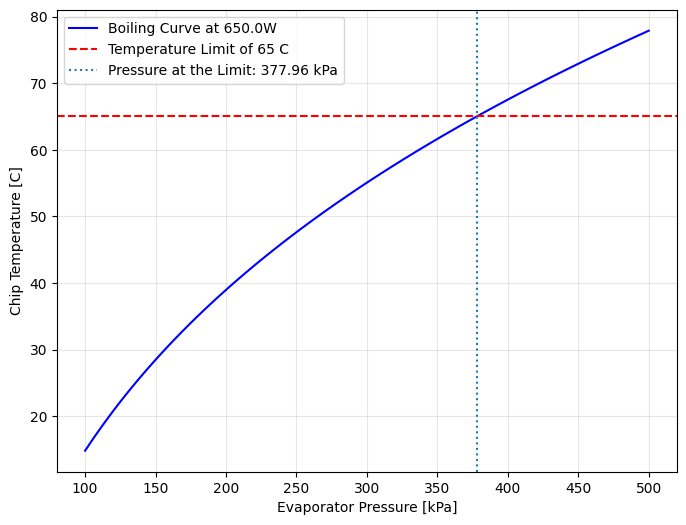

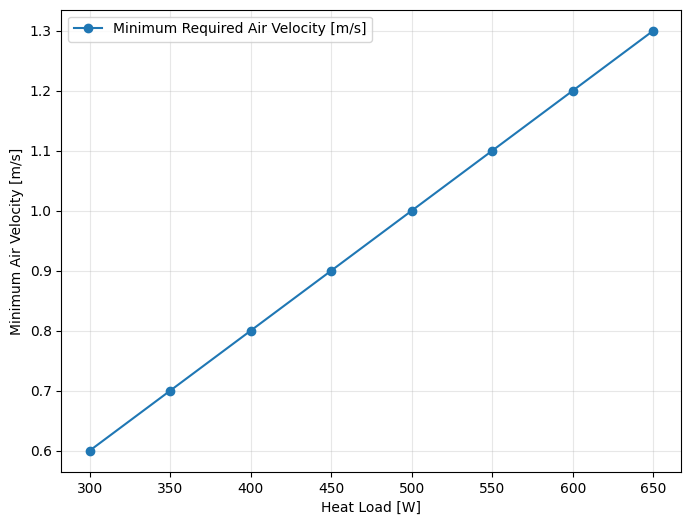

In [70]:
# -------------------------------------------------------------------
#Task 4 Part c
##find the minimum V_a required to maintain T_chip under 65 C while chip heat output fluctuates between 300-650W

q_range = np.arange(300, 651, 50) #[W], take steps of size 50W for exploring the entire range
Va_min = []

print(f"\n{'Heat Load [W]':<14} {'Max Allowable P [kPa]':<24} {'Min Air Velocity [m/s]':<24}")

#loop through the fluctuating chip heat output values to find V_a min that satisfies T_chip < 65
for q in q_range:
    #find the pressure value for which T_chip = 65 C by checking where the pressure curve touches 65C
    P_axis = np.linspace(100, 500, 100) #kPa

    #find T_chip in [degrees C] at each q
    T_test_result_array = np.array(T_wall_calculator(q, A_chip, P_axis)).flatten() - 273.15

    #interpolate to find the pressure corresponding to T=65
    P_limit = np.interp(65.0, T_test_result_array, P_axis)

    #define a test starting value for the air velocity to be looped
    va_test = 0.5
    va_found = False

    #find the min air velocity required at P_limit to achieve saturated liquid (i.e. exit quality = 0)
    while va_test <= 20.0:
        rec_min, q_tot_min, dP_min, Pf_min, xf_min, af_min= condenser_sim(q, Ta_in_C, va_test, P_limit, dz, D, (n_tubes+5), (segments_count + 4)
                                              , rho_a, cp_a, Lf, g)
        if xf_min <= 0.0001:
            Va_min.append(va_test)
            print(f"{q:<15.2f} {P_limit:<25.2f} {va_test:<25.3f}")
            va_found = True
            break

        va_test += 0.1 #increase velocity for next loop

    if not va_found:
        print(f"{q:<15.2f} {P_limit:<25.2f} {'FAILED':<25}")

    # check performance metrics of the condenser
    #print (rec_min, q_tot_min, dP_min, Pf_min, xf_min, af_min)

def visualize_interpolation(q_target):
  P_axis = np.linspace(100, 500, 100)

  T_results = np.array(T_wall_calculator(q_target, A_chip, P_axis)).flatten() - 273.15

  P_limit = np.interp(65.0, T_results, P_axis)

  plt.figure(figsize=(8, 6))

  #plot the curve for the chip
  plt.plot(P_axis, T_results, 'b-', label=f'Boiling Curve at {q_target}W')
  plt.axhline(y=65.0, color='r', linestyle='--', label=f'Temperature Limit of 65 C')
  plt.axvline(x=P_limit, linestyle=':', label=f'Pressure at the Limit: {P_limit:.2f} kPa')

  plt.xlabel('Evaporator Pressure [kPa]')
  plt.ylabel('Chip Temperature [C]')
  plt.grid(True, alpha=0.3)
  plt.legend()
  plt.show()

#plot the interpolation for maxium q
visualize_interpolation(650.0)

#plot the minimum air velocity requried to satisfy 65C vs the varying heat load
plt.figure(figsize=(8, 6))
plt.plot(q_range, Va_min, '-o', label='Minimum Required Air Velocity [m/s]')
plt.xlabel('Heat Load [W]')
plt.ylabel('Minimum Air Velocity [m/s]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
